![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [2]:
import sqlite3

conn = sqlite3.connect("../data/project.db")

def load_queries(path):
    """Read sql/queries.sql and return a dictionary {query_name: sql_text}."""
    queries = {}
    name = None
    for line in open(path):
        if line.startswith("-- name:"):
            name = line.replace("-- name:", "").strip()
            queries[name] = ""
        elif name:
            queries[name] += line
    return queries

queries = load_queries("../sql/queries.sql")
list(queries)

['top_producers_2024',
 'land_yield_price',
 'exporter_price_by_year',
 'importer_price_by_year',
 'top_importers_2024']

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

Coffee is produced in the tropics and drunk mostly in rich importing countries. We use 64 years of FAOSTAT data on green (unroasted) coffee to test two ideas about how land, yield and trade relate to price.

**Q1. Do countries with more coffee land or higher yield (kg/ha) sell their green coffee at a lower export price per kg?**
*Hypothesis:* large, high-yield producers such as Brazil and Viet Nam sell cheaper than smaller, low-yield producers such as Ethiopia and Kenya, because better technology and scale lower the cost per kg.

**Q2. Do importing countries pay more per kg for green coffee than exporting countries receive for it?**
*Hypothesis:* yes. The import price is higher than the export price every year, and the gap has grown over time.

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

**Source:** FAOSTAT (fao.org/faostat), item "Coffee, green", downloaded 25 Sep 2026: production (1961–2024) and trade (1961–2024). A third file, processed coffee (2010–2023), was also downloaded but dropped — under flag A (official values only) it had just 2 usable rows, too sparse to analyze.

**One row** in each fact table = one country, in one year, for one measure (e.g. Brazil, 2024, Production, 3,387,724 t).

**Database:** 3 lookup tables (`countries`, `elements`, `flags`) and 2 fact tables (`production`, `trade`), linked by foreign keys.

![ERD](../images/erd.png)

In [3]:
for t in ["countries", "elements", "flags", "production", "trade"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"{t:<11} {n:>6,} rows")

countries      203 rows
elements         7 rows
flags            1 rows
production   8,082 rows
trade       33,097 rows


---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

In [4]:
queries = load_queries("../sql/queries.sql")
list(queries)

['top_producers_2024',
 'land_yield_price',
 'exporter_price_by_year',
 'importer_price_by_year',
 'top_importers_2024']

In [5]:
def yield_group(yield_kg_ha):
    if yield_kg_ha < 600:
        return "1. Low (< 600 kg/ha)"
    elif yield_kg_ha < 1000:
        return "2. Medium (600-1000 kg/ha)"
    else:
        return "3. High (> 1000 kg/ha)"

land_yield_price = pd.read_sql(queries["land_yield_price"], conn)
land_yield_price["yield_group"] = land_yield_price["avg_yield_kg_ha"].apply(yield_group)

price_by_yield_group = land_yield_price.groupby("yield_group").agg(
    countries=("area_name", "count"),
    avg_export_price_usd_kg=("export_price_usd_kg", "mean")
).round(2).reset_index()

exporters = pd.read_sql(queries["exporter_price_by_year"], conn)
importers = pd.read_sql(queries["importer_price_by_year"], conn)
price_gap_by_year = pd.merge(exporters, importers, on="year")
price_gap_by_year["gap_usd_kg"] = price_gap_by_year["importer_price_usd_kg"] - price_gap_by_year["exporter_price_usd_kg"]
price_gap_by_year["gap_pct"] = price_gap_by_year["gap_usd_kg"] / price_gap_by_year["exporter_price_usd_kg"] * 100

price_gap_summary = price_gap_by_year[price_gap_by_year["year"].isin(
    [1970, 1980, 1990, 2000, 2010, 2020, 2024])][
    ["year", "exporter_price_usd_kg", "importer_price_usd_kg", "gap_usd_kg", "gap_pct"]
]

print("land_yield_price:")
display(land_yield_price.round(2))

print("\nprice_by_yield_group:")
display(price_by_yield_group.round(2))

print("\nprice_gap_by_year (last 5 years):")
display(price_gap_by_year.tail())

print("\nprice_gap_summary:")
display(price_gap_summary.round(2))

land_yield_price:


,area_name,avg_area_ha,avg_yield_kg_ha,avg_export_t,export_price_usd_kg,yield_group
0,Brazil,1894641.80,1575.62,1917315.29,2.62,3. High (> 1000 kg/ha)
1,Indonesia,1255440.50,589.39,371151.07,2.81,1. Low (< 600 kg/ha)
2,Colombia,842056.20,924.55,687586.51,4.05,2. Medium (600-1000 kg/ha)
3,Ethiopia,818386.80,671.62,193920.15,4.20,2. Medium (600-1000 kg/ha)
4,Mexico,640861.14,260.33,98886.66,3.56,1. Low (< 600 kg/ha)
5,Viet Nam,605168.75,2535.70,1462588.73,1.83,3. High (> 1000 kg/ha)
6,India,443862.20,751.08,241142.76,2.66,2. Medium (600-1000 kg/ha)
7,Peru,418791.20,809.40,223819.19,3.52,2. Medium (600-1000 kg/ha)
8,Guatemala,334331.60,699.36,186257.30,4.60,2. Medium (600-1000 kg/ha)
9,Honduras,270000.00,1232.40,285227.99,3.27,3. High (> 1000 kg/ha)



price_by_yield_group:


,yield_group,countries,avg_export_price_usd_kg
0,1. Low (< 600 kg/ha),6,3.24
1,2. Medium (600-1000 kg/ha),7,4.13
2,3. High (> 1000 kg/ha),5,2.71



price_gap_by_year (last 5 years):


,year,exporter_price_usd_kg,importer_price_usd_kg,gap_usd_kg,gap_pct
59,2020,2.829864,2.649455,-0.180409,-6.375191
60,2021,3.020587,2.982172,-0.038415,-1.271775
61,2022,4.403594,4.305955,-0.097639,-2.217265
62,2023,4.057683,4.015598,-0.042085,-1.037169
63,2024,4.635976,4.612329,-0.023647,-0.510083



price_gap_summary:


,year,exporter_price_usd_kg,importer_price_usd_kg,gap_usd_kg,gap_pct
9,1970,0.90,0.96,0.05,5.75
19,1980,3.21,3.67,0.46,14.42
29,1990,1.33,1.69,0.36,27.26
39,2000,1.61,1.76,0.15,9.12
49,2010,3.35,2.95,-0.40,-11.96
59,2020,2.83,2.65,-0.18,-6.38
63,2024,4.64,4.61,-0.02,-0.51


In [6]:
n_years = len(price_gap_by_year)
negative_years = price_gap_by_year[price_gap_by_year["importer_price_usd_kg"] < price_gap_by_year["exporter_price_usd_kg"]]
avg_gap_pct = ((price_gap_by_year["importer_price_usd_kg"] - price_gap_by_year["exporter_price_usd_kg"])
               / price_gap_by_year["exporter_price_usd_kg"] * 100).mean()

print(f"Total years: {n_years}")
print(f"Years importer paid LESS than exporter received: {len(negative_years)}")
print("Which years:", list(negative_years["year"]))
print(f"Average gap across all years: {avg_gap_pct:.1f}%")

Total years: 64
Years importer paid LESS than exporter received: 10
Which years: [2006, 2007, 2010, 2014, 2019, 2020, 2021, 2022, 2023, 2024]
Average gap across all years: 10.0%


In [7]:
corr_area  = land_yield_price["avg_area_ha"].corr(land_yield_price["export_price_usd_kg"], method="spearman")
corr_yield = land_yield_price["avg_yield_kg_ha"].corr(land_yield_price["export_price_usd_kg"], method="spearman")
print("Correlation area - price:", round(corr_area, 2))
print("Correlation yield - price:", round(corr_yield, 2))

Correlation area - price: -0.16
Correlation yield - price: -0.26


In [8]:
pd.read_sql(queries["top_producers_2024"], conn)

,area_name,production_t,area_ha,yield_kg_ha
0,Brazil,3387724.00,1943977.0,1742.7
1,Viet Nam,2015289.00,678569.0,2969.9
2,Colombia,839846.69,837685.0,1002.6
3,Indonesia,807578.00,1269354.0,636.2
4,India,363000.00,491419.0,738.7
5,Peru,358993.78,421972.0,850.8
6,Guatemala,224860.00,376019.0,598.0
7,Lao People's Democratic Republic,174900.00,91730.0,1906.7
8,Costa Rica,62153.98,82539.0,753.0
9,Kenya,49500.00,113600.0,435.7


---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

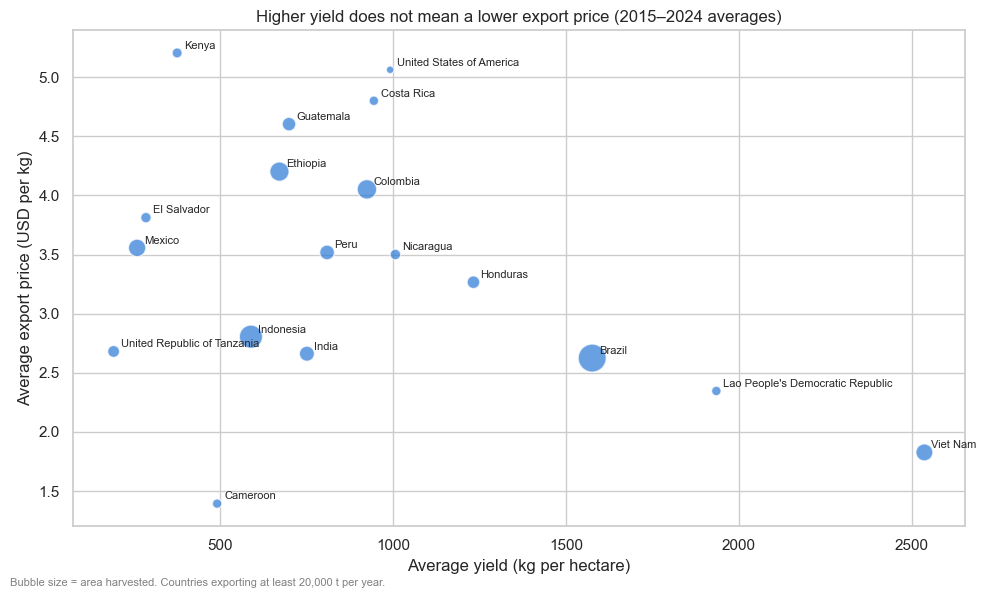

In [9]:
land_yield_price = pd.read_sql(queries["land_yield_price"], conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(land_yield_price["avg_yield_kg_ha"], land_yield_price["export_price_usd_kg"],
           s=30 + land_yield_price["avg_area_ha"] / 5000,
           color="#2a78d6", alpha=0.7, edgecolor="white")
for _, row in land_yield_price.iterrows():
    ax.annotate(row["area_name"], (row["avg_yield_kg_ha"], row["export_price_usd_kg"]),
                fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set_title("Higher yield does not mean a lower export price (2015–2024 averages)")
ax.set_xlabel("Average yield (kg per hectare)")
ax.set_ylabel("Average export price (USD per kg)")
fig.text(0.01, 0.01, "Bubble size = area harvested. Countries exporting at least 20,000 t per year.",
         fontsize=8, color="grey")
plt.tight_layout()
plt.show()

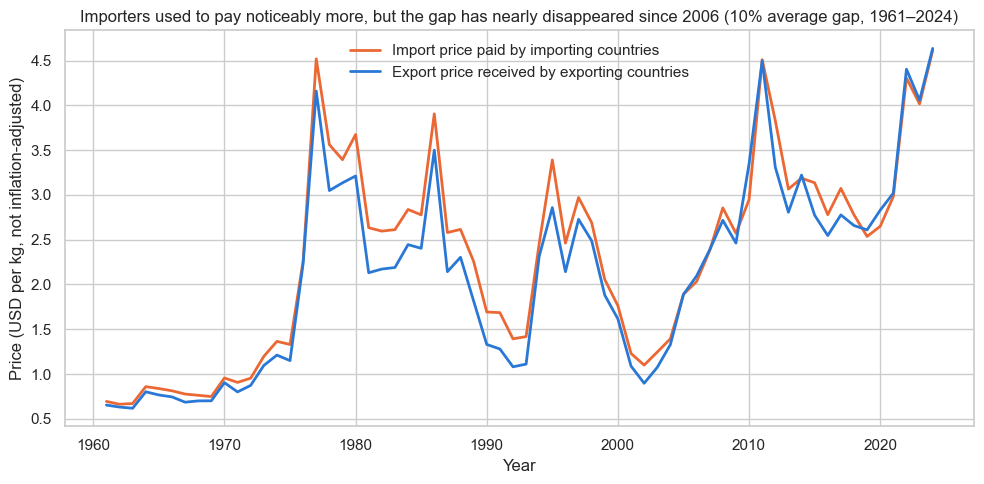

In [10]:
price_gap = price_gap_by_year   # reuse the dataframe already built in Section 3

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(price_gap["year"], price_gap["importer_price_usd_kg"], color="#eb6834", lw=2,
        label="Import price paid by importing countries")
ax.plot(price_gap["year"], price_gap["exporter_price_usd_kg"], color="#2a78d6", lw=2,
        label="Export price received by exporting countries")
ax.set_title("Importers used to pay noticeably more, but the gap has nearly disappeared since 2006 (10% average gap, 1961–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Price (USD per kg, not inflation-adjusted)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 5. Conclusions

Answer each question. Say whether your hypothesis held. Being wrong is a fine result, as long as you say so and show the evidence.

## 5. Conclusions

**Q1: Do countries with more land or higher yield sell coffee at a lower export price?**

**Hypothesis weakly supported.** Both correlations point the way the hypothesis predicted — larger, higher-yield producers tend to sell cheaper — but only weakly: Spearman correlation is -0.16 for area and -0.26 for yield. The clearest evidence is the two biggest producers: Viet Nam has the highest yield in the set (2,536 kg/ha) and the cheapest export price (1.83 USD/kg), and Brazil, the largest producer by area, is also one of the cheaper countries (2.62 USD/kg). But the pattern isn't consistent — grouping countries by yield tier gives 3.24 USD/kg for low-yield, 4.13 for medium-yield (the most expensive group), and 2.71 for high-yield, so it isn't a straight line, and some low-yield countries (Cameroon, 1.39 USD/kg) are just as cheap as the high-yield leaders. Kenya, at the other extreme, has both low yield (376 kg/ha) and the highest price (5.21 USD/kg), which does fit.

**How confident should you be?** Not very. This is based on only 18 countries with complete official (flag A) area, yield, and export figures over 2015–2024, and the pattern is driven mainly by two countries (Brazil, Viet Nam) rather than a broad trend across all 18.

**Q2: Do importing countries pay more per kg than exporting countries receive?**

**Hypothesis partly supported, but not in the way expected.** Importing countries paid more than exporting countries received in 54 of 64 years (84%) — so the first half of the hypothesis mostly holds. But the second half is wrong: the gap has not grown over time, it has shrunk and nearly disappeared. It peaked around 1990 (importers paid 27% more) and was still sizeable in 1980 (14%) and 2000 (9%), but by 2010 the gap had turned slightly negative (-12%) and stayed near zero or negative through 2020 (-6%) and 2024 (-0.5%). All 10 years where exporters received as much or more than importers paid fall in 2006 or later.

**How confident should you be?** Fairly confident about the historical pattern (importers paying more, 1961 through the mid-2000s) — it holds in the large majority of years. Less confident about why the gap has narrowed so much since 2006; this data doesn't say whether it's cheaper shipping, currency effects, or something else.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.

**Limitations**
- **Not the farmer's price.** The export price is value ÷ quantity at the border (USD/kg). What farmers receive is lower and is not in this data.
- **No coffee type.** The data does not separate arabica from robusta. Coffee type might still explain some of the price differences between countries, but since area, yield, and scale all show little to no relationship with price here, we can't point to any single alternative explanation from this data alone.
- **Nominal prices.** Prices are not adjusted for inflation, so price levels over time are not directly comparable. The gap between the two lines still is.
- **Official values only.** We kept only rows flagged **A** (official), dropping estimated, imputed, and mandated-organization values (flags E, I, X). This cuts the data a lot — coverage is patchier in earlier decades and for smaller countries that report late or not at all — but every number that remains is one FAOSTAT vouches for directly, not an estimate.
- **Exporter/importer groups.** Countries are labelled by net trade each year (exports > imports), so a few switch groups between years.
- **Re-exporters.** Countries like Germany and Belgium import coffee and re-export part of it. They count as importers here.
- **Yield ≠ technology.** We use yield as a proxy for technology, but yield also depends on climate, soil and tree age.

**Next steps (with another week)**
- Add FAOSTAT *Producer Prices* to compare the farm price with the export price and see how much the farmer gets.
- Add the arabica/robusta share per country to test whether coffee type explains the price differences in Q1.
- Adjust prices for inflation to see the real price trend.
- Add roasted coffee trade (also in FAOSTAT) to measure where the big markup happens after import.
- Investigate why the import-export price gap has narrowed and nearly disappeared since 2006, after being sizeable (10–27%) for most of 1961–2005 — a currency, shipping-cost, trade-agreement, or data-reporting explanation may be behind this recent shift.